# Notebook 04: Activation Patching

## Goal
Causally verify that the features we identified in Notebook 03 actually **drive** the model's behavior, 
not just correlate with it.

## Core idea
Activation patching asks: "If I swap the internal activations from prompt A into a run of prompt B, 
does the output change toward A's output?"

If yes, those activations (and the features they contain) are causally responsible.

## Experiments
1. **Whole-residual patching**: Patch entire residual stream at layer 12 from a math prompt into a creative prompt
2. **Feature-direction patching**: Only patch along the top discriminative feature directions
3. **Layer-by-layer sweep**: Patch at each layer to find where the causal information is concentrated
4. **(Optional) Feature steering**: Amplify math features on a neutral prompt — does output become math-like?

In [3]:
import torch
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F

# Patch transformers compat before importing transformer_lens
import transformers
for _cls in ("BertForPreTraining", "T5ForConditionalGeneration"):
    if not hasattr(transformers, _cls):
        setattr(transformers, _cls, type(_cls, (), {}))

from transformer_lens import HookedTransformer
from sae_lens import SAE

SEED = 42
torch.manual_seed(SEED)

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"

with open("results/config.json", encoding="utf-8") as f:
    cfg = json.load(f)

MODEL_NAME    = cfg["model_name"]
MODEL_DEVICE  = cfg["model_device"]
TARGET_LAYERS = cfg["target_layers"]
SAE_RELEASE   = cfg["sae_release"]
MIDDLE_LAYER  = TARGET_LAYERS[1]

# Use float32 for activation patching — bfloat16 can cause CUBLAS errors
# on consumer GPUs (RTX 3050 Ti) during the many hooked forward passes.
# GPT-2 at float32 is only ~500MB, well within VRAM.
MODEL_DTYPE = "float32"

SAE_HOOK  = "hook_resid_pre" if "gpt2" in SAE_RELEASE else "hook_resid_post"
POST_HOOK = "hook_resid_post"

print(f"Model:        {MODEL_NAME}  on  {MODEL_DEVICE}")
print(f"Dtype:        {MODEL_DTYPE} (float32 for patching stability)")
print(f"Middle layer: {MIDDLE_LAYER}")
print(f"SAE hook:     blocks.N.{SAE_HOOK}")


Model:        gpt2  on  cuda
Dtype:        float32 (float32 for patching stability)
Middle layer: 6
SAE hook:     blocks.N.hook_resid_pre


In [4]:
print(f'Loading {MODEL_NAME} on {MODEL_DEVICE}...')
model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    dtype=MODEL_DTYPE,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
    device=MODEL_DEVICE,
)
model.eval()

# Only need the middle layer SAE for patching experiments
if 'gpt2' in SAE_RELEASE:
    sae_id = f'blocks.{MIDDLE_LAYER}.hook_resid_pre'
else:
    sae_id = f'layer_{MIDDLE_LAYER}/width_16k/average_l0_71'

print(f'Loading SAE: {sae_id}')
sae = SAE.from_pretrained(release=SAE_RELEASE, sae_id=sae_id, device=MODEL_DEVICE)
sae.eval()

print(f'Model loaded: {model.cfg.n_layers} layers, d_model={model.cfg.d_model}')
print(f'SAE loaded:   {sae.cfg.d_sae} features')

Loading gpt2 on cuda...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Loading SAE: blocks.6.hook_resid_pre
Model loaded: 12 layers, d_model=768
SAE loaded:   24576 features


C:\Users\mukho\AppData\Local\Programs\Python\Python311\Lib\site-packages\sae_lens\saes\sae.py:249: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [5]:
CLEAN_PROMPT   = 'The answer to 15 plus 27 is'
CORRUPT_PROMPT = 'Once upon a time in a forest'

with torch.no_grad():
    clean_logits  = model(model.to_tokens(CLEAN_PROMPT))
    corrupt_logits = model(model.to_tokens(CORRUPT_PROMPT))

def show_top5(logits, label):
    top5 = logits[0, -1].topk(5)
    print(label)
    for idx, val in zip(top5.indices, top5.values):
        print(f'  "{model.to_string([idx.item()])}": {val.item():.2f}')

show_top5(clean_logits,   f'Clean:   "{CLEAN_PROMPT}"')
print()
show_top5(corrupt_logits, f'Corrupt: "{CORRUPT_PROMPT}"')

Clean:   "The answer to 15 plus 27 is"
  " "": -95.32
  ":": -95.39
  " a": -96.33
  " not": -96.44
  " to": -96.59

Corrupt: "Once upon a time in a forest"
  ",": -63.14
  ".": -65.36
  "ed": -65.72
  " in": -65.78
  " the": -66.44


In [6]:
# Experiment 1: Whole-residual patch at middle layer
patch_hook_name = f'blocks.{MIDDLE_LAYER}.{POST_HOOK}'

with torch.no_grad():
    _, clean_cache = model.run_with_cache(
        model.to_tokens(CLEAN_PROMPT), names_filter=patch_hook_name
    )
clean_resid_mid = clean_cache[patch_hook_name][0, -1, :].clone()

def whole_patch_hook(value, hook):
    value[0, -1, :] = clean_resid_mid
    return value

with torch.no_grad():
    with model.hooks(fwd_hooks=[(patch_hook_name, whole_patch_hook)]):
        patched_logits = model(model.to_tokens(CORRUPT_PROMPT))

print(f'After full patch at layer {MIDDLE_LAYER}:')
show_top5(patched_logits, f'Patched: "{CORRUPT_PROMPT}"')

After full patch at layer 6:
Patched: "Once upon a time in a forest"
  " that": -88.77
  " a": -89.50
  " the": -89.86
  " always": -90.23
  " to": -90.32


In [7]:
# Experiment 2: Layer-by-layer sweep — cache all post-block residuals
all_post_hooks = [f'blocks.{l}.{POST_HOOK}' for l in range(model.cfg.n_layers)]

with torch.no_grad():
    _, clean_cache_all = model.run_with_cache(
        model.to_tokens(CLEAN_PROMPT), names_filter=all_post_hooks
    )

clean_prob   = F.softmax(clean_logits[0, -1].float(), dim=-1)
kl_per_layer = []

for layer_idx in range(model.cfg.n_layers):
    hook_name   = f'blocks.{layer_idx}.{POST_HOOK}'
    clean_resid = clean_cache_all[hook_name][0, -1, :].clone()

    def make_hook(cr):
        def hook_fn(value, hook):
            value[0, -1, :] = cr
            return value
        return hook_fn

    with torch.no_grad():
        with model.hooks(fwd_hooks=[(hook_name, make_hook(clean_resid))]):
            patched = model(model.to_tokens(CORRUPT_PROMPT))

    patched_prob = F.softmax(patched[0, -1].float(), dim=-1)
    kl = F.kl_div(patched_prob.log(), clean_prob, reduction='sum').item()
    kl_per_layer.append(kl)

best_layer = int(np.argmin(kl_per_layer))
print('KL from clean per layer (lower = more similar to clean):')
for l, kl in enumerate(kl_per_layer):
    tag = ' <-- most informative' if l == best_layer else ''
    print(f'  Layer {l:2d}: {kl:.4f}{tag}')

KL from clean per layer (lower = more similar to clean):
  Layer  0: 5.0839
  Layer  1: 4.7583
  Layer  2: 2.4157
  Layer  3: 2.2046
  Layer  4: 1.5909
  Layer  5: 0.9388
  Layer  6: 0.6379
  Layer  7: 0.4770
  Layer  8: 0.1605
  Layer  9: 0.0636
  Layer 10: 0.0068
  Layer 11: 0.0000 <-- most informative


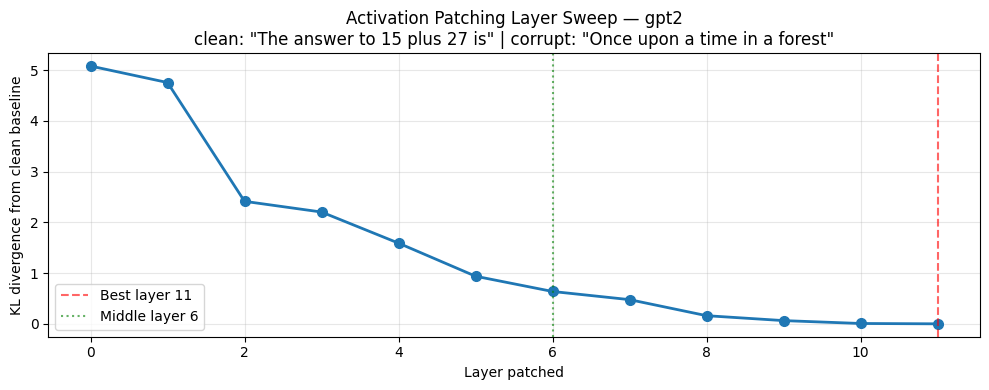

Most causally informative layer: 11


In [8]:
plt.figure(figsize=(10, 4))
plt.plot(range(model.cfg.n_layers), kl_per_layer, 'o-', linewidth=2, markersize=7)
plt.axvline(x=best_layer,   color='red',   linestyle='--', alpha=0.6, label=f'Best layer {best_layer}')
plt.axvline(x=MIDDLE_LAYER, color='green', linestyle=':',  alpha=0.6, label=f'Middle layer {MIDDLE_LAYER}')
plt.xlabel('Layer patched')
plt.ylabel('KL divergence from clean baseline')
plt.title(f'Activation Patching Layer Sweep — {MODEL_NAME}\n'
          f'clean: "{CLEAN_PROMPT}" | corrupt: "{CORRUPT_PROMPT}"')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'patching_by_layer.png', dpi=150)
plt.show()
print(f'Most causally informative layer: {best_layer}')

In [9]:
# Experiment 3: Surgical feature-direction patching
# Load discriminative features saved by notebook 03
with open('results/discriminative_features.json', encoding='utf-8') as f:
    disc = json.load(f)

math_indices   = disc['math']['indices'][:20]
math_indices_t = torch.tensor(math_indices, device=MODEL_DEVICE)

# SAE decoder rows = feature directions in activation space [n_features, d_model]
math_directions = sae.W_dec[math_indices_t].float()  # [20, d_model]
print(f'Feature direction matrix: {math_directions.shape}')

# Get clean residual at the SAE hook point
sae_hook_name = f'blocks.{MIDDLE_LAYER}.{SAE_HOOK}'
with torch.no_grad():
    _, sae_cache = model.run_with_cache(
        model.to_tokens(CLEAN_PROMPT), names_filter=sae_hook_name
    )
clean_resid_sae = sae_cache[sae_hook_name][0, -1, :].float()
print(f'Clean residual at {sae_hook_name}: {clean_resid_sae.shape}')

Feature direction matrix: torch.Size([10, 768])
Clean residual at blocks.6.hook_resid_pre: torch.Size([768])


In [10]:
def surgical_hook(value, hook):
    """Replace the corrupt component along each math feature direction with the clean one."""
    corrupt = value[0, -1, :].float()
    for dir_vec in math_directions:
        d = dir_vec / (dir_vec.norm() + 1e-8)
        corrupt = corrupt - (corrupt * d).sum() * d          # remove corrupt
        corrupt = corrupt + (clean_resid_sae * d).sum() * d  # add clean
    value[0, -1, :] = corrupt.to(value.dtype)
    return value

with torch.no_grad():
    with model.hooks(fwd_hooks=[(sae_hook_name, surgical_hook)]):
        surgical_logits = model(model.to_tokens(CORRUPT_PROMPT))

def kl_from_clean(logits):
    p = F.softmax(logits[0, -1].float(), dim=-1)
    return F.kl_div(p.log(), clean_prob, reduction='sum').item()

print('KL from clean baseline (lower = more math-like):')
print(f'  No patch (baseline):  {kl_from_clean(corrupt_logits):.4f}')
print(f'  Full residual patch:  {kl_from_clean(patched_logits):.4f}')
print(f'  Surgical (math dirs): {kl_from_clean(surgical_logits):.4f}')
print()
show_top5(surgical_logits, f'Surgical patch: "{CORRUPT_PROMPT}"')

KL from clean baseline (lower = more math-like):
  No patch (baseline):  3.6125
  Full residual patch:  0.6379
  Surgical (math dirs): 3.4796

Surgical patch: "Once upon a time in a forest"
  ",": -60.65
  " in": -62.80
  ".": -63.16
  " of": -63.38
  " there": -63.64


In [11]:
# (Optional) Experiment 4: Feature steering
steering_vector = math_directions.mean(dim=0)  # [d_model]
ALPHA = 20

def steering_hook(value, hook):
    value[:, :, :] = value[:, :, :] + ALPHA * steering_vector.to(value.dtype)
    return value

neutral_prompt = 'Tell me something interesting about the world.'

with torch.no_grad():
    baseline_out = model.generate(
        model.to_tokens(neutral_prompt), max_new_tokens=30, temperature=1.0
    )

with torch.no_grad():
    with model.hooks(fwd_hooks=[(sae_hook_name, steering_hook)]):
        steered_out = model.generate(
            model.to_tokens(neutral_prompt), max_new_tokens=30, temperature=1.0
        )

print(f'Prompt: "{neutral_prompt}"')
print(f'\nBaseline:\n  {model.to_string(baseline_out[0])}')
print(f'\nMath-steered (alpha={ALPHA}):\n  {model.to_string(steered_out[0])}')

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Prompt: "Tell me something interesting about the world."

Baseline:
  <|endoftext|>Tell me something interesting about the world. Like how does Shohei Zou will overcome his dislocation by outshining his opposition?

Well, there doesn't seem to be anything

Math-steered (alpha=20):
  <|endoftext|>Tell me something interesting about the world.

My brain really gets things done on the Internet. And whenever I find someone playing, I add them to the fun. Everyone gets a chance


## Reflection Questions

1. **Full patch vs. surgical patch**: The surgical patch (only math feature directions) should reduce KL divergence less than the full patch, but it operates on fewer dimensions. What does the *ratio* of their effects tell you?

2. **Layer sweep**: At which layer(s) does patching have the most effect? Does this match your expectation from the separability analysis in Notebook 03?

3. **Steering**: Does amplifying math features produce math-like content in the output? If the steering doesn't work well, why might that be (think: what else is changing when you add a vector to all positions)?

4. **Causality**: Activation patching gives us *causal* evidence that specific features drive behavior. How is this different from just observing that features activate for math prompts (correlation)?